# Deep Learning com PyTorch — Tutorial Completo

Neste notebook vamos aprender os fundamentos do PyTorch e construir uma rede neural do zero.

## Estrutura
1. **Tensores** — a estrutura de dados fundamental do PyTorch
2. **Autograd** — diferenciação automática
3. **Rede Neural** — classificação do Iris dataset com `nn.Module`
4. **Loop de Treino** — forward, loss, backward, update
5. **Avaliação** — métricas e curvas de aprendizado
6. **Predições** — inferência com novos dados


---
## 1. Importações

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.style.use('seaborn-v0_8-whitegrid')

# Reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch versão: {torch.__version__}')
print(f'Dispositivo disponível: {"GPU (CUDA)" if torch.cuda.is_available() else "CPU"}')

PyTorch versão: 2.11.0
Dispositivo disponível: CPU


---
## 2. Tensores — A Estrutura de Dados do PyTorch

Tensores são arrays N-dimensionais, semelhantes ao `np.ndarray`, mas com:
- Suporte a **GPU**
- **Autograd** — rastreamento de gradientes automático

In [ ]:
print('=== Criando Tensores ===')

# A partir de listas
t1 = torch.tensor([1.0, 2.0, 3.0])
print(f't1 = {t1}  |  dtype: {t1.dtype}  |  shape: {t1.shape}')

# Matriz
t2 = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
print(f't2:\n{t2}  |  shape: {t2.shape}')

# Tensores especiais
print(f'\nzeros(2,3):\n{torch.zeros(2, 3)}')
print(f'\nones(2,3):\n{torch.ones(2, 3)}')
print(f'\nrandn(2,3) — normal(0,1):\n{torch.randn(2, 3).round(decimals=3)}')


In [7]:
print('=== Operações com Tensores ===')

a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(f'a + b = {a + b}')
print(f'a * b = {a * b}  (element-wise)')
print(f'a @ b = {a @ b}  (produto interno / dot product)')

# Reshape
x = torch.arange(12, dtype=torch.float32)
print(f'\nx (shape {x.shape}): {x}')
print(f'x.reshape(3,4):\n{x.reshape(3, 4)}')

# Conversão NumPy ↔ Tensor
arr = np.array([1, 2, 3])
t_from_np = torch.from_numpy(arr)
np_from_t  = t_from_np.numpy()
print(f'\nNumPy → Tensor: {t_from_np}  |  Tensor → NumPy: {np_from_t}')

=== Operações com Tensores ===
a + b = tensor([5., 7., 9.])
a * b = tensor([ 4., 10., 18.])  (element-wise)
a @ b = 32.0  (produto interno / dot product)

x (shape torch.Size([12])): tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])
x.reshape(3,4):
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

NumPy → Tensor: tensor([1, 2, 3])  |  Tensor → NumPy: [1 2 3]


---
## 3. Autograd — Diferenciação Automática

O PyTorch rastreia todas as operações sobre tensores com `requires_grad=True` e calcula gradientes automaticamente via `backward()`.

In [8]:
print('=== Exemplo de Autograd ===')

# Pesos (parâmetros treináveis)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# Dado de entrada
x = torch.tensor(3.0)
y_true = torch.tensor(10.0)

# Forward pass: ŷ = w*x + b
y_pred = w * x + b
print(f'w={w.item()}, x={x.item()}, b={b.item()}')
print(f'ŷ = w·x + b = {w.item()}·{x.item()} + {b.item()} = {y_pred.item()}')

# Perda (MSE simplificado)
loss = (y_pred - y_true) ** 2
print(f'y_true = {y_true.item()}')
print(f'loss = (ŷ - y)² = ({y_pred.item()} - {y_true.item()})² = {loss.item()}')

# Backward pass — calcula gradientes
loss.backward()

print(f'\n∂loss/∂w = {w.grad.item():.4f}')
print(f'∂loss/∂b = {b.grad.item():.4f}')
print(f'\nVerificação manual:')
print(f'  ∂loss/∂w = 2·(ŷ-y)·x = 2·({y_pred.item()}-{y_true.item()})·{x.item()} = {2*(y_pred.item()-y_true.item())*x.item():.4f}')
print(f'  ∂loss/∂b = 2·(ŷ-y)   = 2·({y_pred.item()}-{y_true.item()})            = {2*(y_pred.item()-y_true.item()):.4f}')

=== Exemplo de Autograd ===
w=2.0, x=3.0, b=1.0
ŷ = w·x + b = 2.0·3.0 + 1.0 = 7.0
y_true = 10.0
loss = (ŷ - y)² = (7.0 - 10.0)² = 9.0

∂loss/∂w = -18.0000
∂loss/∂b = -6.0000

Verificação manual:
  ∂loss/∂w = 2·(ŷ-y)·x = 2·(7.0-10.0)·3.0 = -18.0000
  ∂loss/∂b = 2·(ŷ-y)   = 2·(7.0-10.0)            = -6.0000


In [9]:
print('=== Gradient Descent Manual — 1 Passo ===')

lr = 0.01
print(f'Antes:  w={w.item():.4f}, b={b.item():.4f}')

# Atualização manual (sem optimizer)
with torch.no_grad():  # não rastrear esta operação
    w -= lr * w.grad
    b -= lr * b.grad

# Zerar gradientes para próxima iteração
w.grad.zero_()
b.grad.zero_()

print(f'Depois: w={w.item():.4f}, b={b.item():.4f}')
print(f'\nEm prática, optimizer.step() + optimizer.zero_grad() fazem isso automaticamente.')

=== Gradient Descent Manual — 1 Passo ===
Antes:  w=2.0000, b=1.0000
Depois: w=2.1800, b=1.0600

Em prática, optimizer.step() + optimizer.zero_grad() fazem isso automaticamente.


---
## 4. Ativações — Visualizando as Funções

Vamos plotar as principais funções de ativação e seus gradientes.

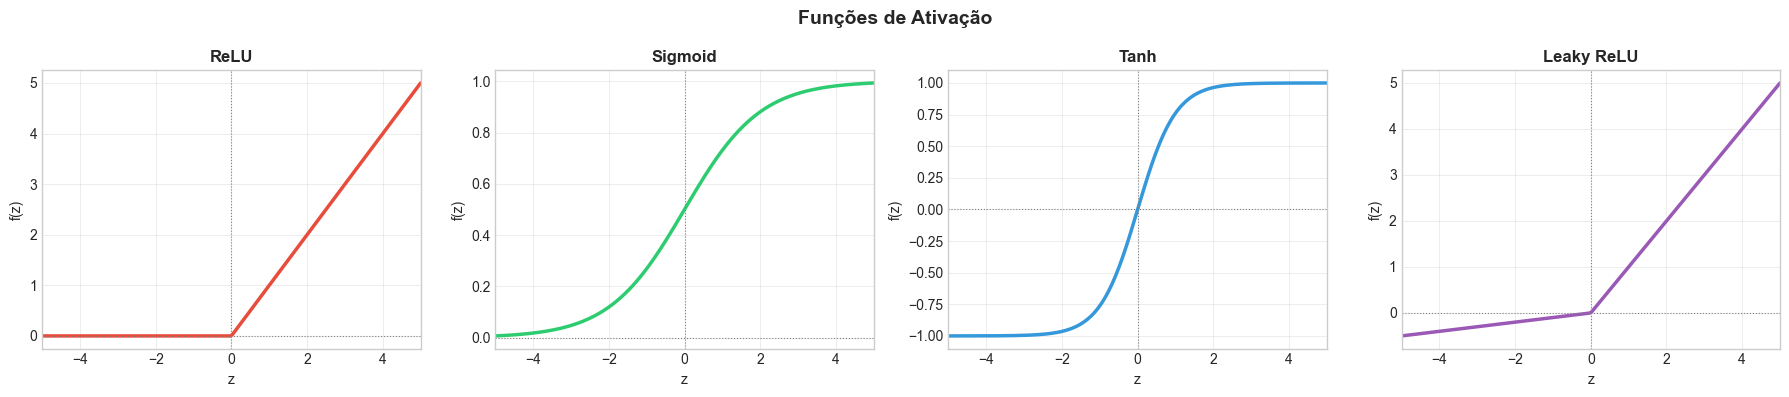

In [10]:
z = torch.linspace(-5, 5, 200)

ativacoes = {
    'ReLU': F.relu(z),
    'Sigmoid': torch.sigmoid(z),
    'Tanh': torch.tanh(z),
    'Leaky ReLU': F.leaky_relu(z, 0.1),
}

cores = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Funções de Ativação', fontsize=14, fontweight='bold')

for ax, (nome, valores), cor in zip(axes, ativacoes.items(), cores):
    ax.plot(z.numpy(), valores.numpy(), color=cor, lw=2.5)
    ax.axhline(0, color='gray', lw=0.8, linestyle=':')
    ax.axvline(0, color='gray', lw=0.8, linestyle=':')
    ax.set_title(nome, fontsize=12, fontweight='bold')
    ax.set_xlabel('z', fontsize=10)
    ax.set_ylabel('f(z)', fontsize=10)
    ax.set_xlim(-5, 5)

plt.tight_layout()
plt.show()

---
## 5. Preparando os Dados — Iris Dataset

In [11]:
iris = load_iris()
X_np = iris.data.astype(np.float32)
y_np = iris.target

# Divisão treino / validação / teste (70 / 15 / 15)
X_train_np, X_temp_np, y_train_np, y_temp_np = train_test_split(
    X_np, y_np, test_size=0.30, random_state=42, stratify=y_np
)
X_val_np, X_test_np, y_val_np, y_test_np = train_test_split(
    X_temp_np, y_temp_np, test_size=0.50, random_state=42, stratify=y_temp_np
)

# Normalização
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_val_np   = scaler.transform(X_val_np)
X_test_np  = scaler.transform(X_test_np)

print('=== Divisão dos Dados ===')
print(f'Treino:    {X_train_np.shape[0]} amostras')
print(f'Validação: {X_val_np.shape[0]} amostras')
print(f'Teste:     {X_test_np.shape[0]} amostras')

=== Divisão dos Dados ===
Treino:    105 amostras
Validação: 22 amostras
Teste:     23 amostras


In [12]:
# Converter para tensores PyTorch
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)  # long para CrossEntropyLoss
X_val   = torch.tensor(X_val_np,   dtype=torch.float32)
y_val   = torch.tensor(y_val_np,   dtype=torch.long)
X_test  = torch.tensor(X_test_np,  dtype=torch.float32)
y_test  = torch.tensor(y_test_np,  dtype=torch.long)

# DataLoader para mini-batches
train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f'Tensores criados!')
print(f'X_train: {X_train.shape}  dtype: {X_train.dtype}')
print(f'y_train: {y_train.shape}  dtype: {y_train.dtype}')
print(f'\nBatches por epoch: {len(train_loader)}')
print(f'Batch size: 16')

Tensores criados!
X_train: torch.Size([105, 4])  dtype: torch.float32
y_train: torch.Size([105])  dtype: torch.int64

Batches por epoch: 7
Batch size: 16


---
## 6. Definindo a Rede Neural

Usamos `nn.Module` — a classe base de todos os modelos PyTorch.

**Arquitetura:**
```
Input (4) → Linear(4→64) → ReLU → Dropout(0.3)
          → Linear(64→32) → ReLU → Dropout(0.3)
          → Linear(32→3) → (CrossEntropyLoss inclui Softmax)
```

In [13]:
class IrisNet(nn.Module):
    def __init__(self, input_size=4, hidden1=64, hidden2=32, output_size=3, dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, output_size)
            # sem Softmax aqui — nn.CrossEntropyLoss já aplica internamente
        )

    def forward(self, x):
        return self.network(x)


model = IrisNet()

print('=== Arquitetura da Rede ===')
print(model)

total_params = sum(p.numel() for p in model.parameters())
treinaveis   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal de parâmetros: {total_params}')
print(f'Parâmetros treináveis: {treinaveis}')

=== Arquitetura da Rede ===
IrisNet(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)

Total de parâmetros: 2499
Parâmetros treináveis: 2499


In [14]:
# Testar um forward pass antes de treinar
with torch.no_grad():
    exemplo = X_train[:3]  # 3 amostras
    logits = model(exemplo)
    probs = F.softmax(logits, dim=1)

print('=== Teste do Forward Pass ===')
print(f'Input shape:  {exemplo.shape}')
print(f'Logits shape: {logits.shape}')
print(f'\nLogits (saída bruta, antes do Softmax):')
print(logits.round(decimals=4))
print(f'\nProbabilidades (após Softmax):')
print(probs.round(decimals=4))
print(f'Soma das probs (deve ser 1.0): {probs.sum(dim=1)}')

=== Teste do Forward Pass ===
Input shape:  torch.Size([3, 4])
Logits shape: torch.Size([3, 3])

Logits (saída bruta, antes do Softmax):
tensor([[ 0.0166, -0.0184,  0.1130],
        [ 0.1374, -0.1453,  0.2018],
        [ 0.0433,  0.1042,  0.4210]])

Probabilidades (após Softmax):
tensor([[0.3261, 0.3149, 0.3591],
        [0.3546, 0.2673, 0.3782],
        [0.2839, 0.3018, 0.4143]])
Soma das probs (deve ser 1.0): tensor([1.0000, 1.0000, 1.0000])


---
## 7. Configurando Loss e Otimizador

In [15]:
criterion = nn.CrossEntropyLoss()          # loss para multiclasse
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Scheduler: reduz lr quando a validação para de melhorar
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

print('Loss:      nn.CrossEntropyLoss')
print('Otimizador: Adam (lr=1e-3)')
print('Scheduler:  ReduceLROnPlateau (fator 0.5, patience 10)')

Loss:      nn.CrossEntropyLoss
Otimizador: Adam (lr=1e-3)
Scheduler:  ReduceLROnPlateau (fator 0.5, patience 10)


---
## 8. Loop de Treinamento

O loop padrão do PyTorch:
1. **Forward** — calcula predições
2. **Loss** — mede o erro
3. **Zero grad** — limpa gradientes do passo anterior
4. **Backward** — calcula gradientes
5. **Step** — atualiza pesos

In [16]:
def calcular_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        preds = logits.argmax(dim=1)
        return (preds == y).float().mean().item()


n_epochs = 150
historico = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Treinando...\n')
print(f'{"Epoch":>6} | {"Train Loss":>11} | {"Val Loss":>10} | {"Train Acc":>10} | {"Val Acc":>9}')
print('-' * 58)

for epoch in range(1, n_epochs + 1):
    # --- TREINO ---
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        logits = model(X_batch)          # 1. Forward
        loss = criterion(logits, y_batch) # 2. Loss
        optimizer.zero_grad()             # 3. Zero grad
        loss.backward()                   # 4. Backward
        optimizer.step()                  # 5. Update
        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # --- VALIDAÇÃO ---
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val)
        val_loss   = criterion(val_logits, y_val).item()

    scheduler.step(val_loss)

    train_acc = calcular_accuracy(model, X_train, y_train)
    val_acc   = calcular_accuracy(model, X_val, y_val)

    historico['train_loss'].append(train_loss)
    historico['val_loss'].append(val_loss)
    historico['train_acc'].append(train_acc)
    historico['val_acc'].append(val_acc)

    if epoch % 25 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>11.4f} | {val_loss:>10.4f} | {train_acc:>10.2%} | {val_acc:>9.2%}')

print('\nTreinamento concluído!')

Treinando...

 Epoch |  Train Loss |   Val Loss |  Train Acc |   Val Acc
----------------------------------------------------------
     1 |      1.1350 |     1.0795 |     40.95% |    45.45%
    25 |      0.2222 |     0.2682 |     95.24% |    86.36%
    50 |      0.1008 |     0.1869 |     97.14% |    86.36%
    75 |      0.0682 |     0.1935 |     97.14% |    86.36%
   100 |      0.0655 |     0.1931 |     98.10% |    86.36%
   125 |      0.0762 |     0.1968 |     98.10% |    86.36%
   150 |      0.0763 |     0.1971 |     98.10% |    86.36%

Treinamento concluído!


---
## 9. Curvas de Aprendizado

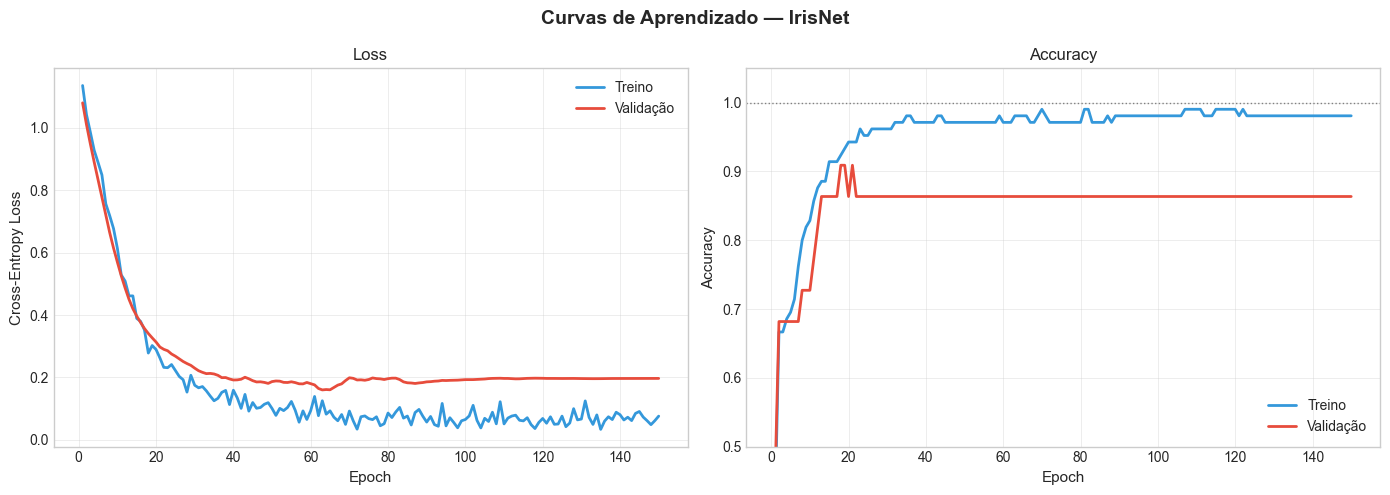

Melhor val_loss:  0.1602  (epoch 63)
Melhor val_acc:   90.91%  (epoch 18)


In [17]:
epochs = range(1, n_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizado — IrisNet', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, historico['train_loss'], label='Treino', color='#3498db', lw=2)
axes[0].plot(epochs, historico['val_loss'],   label='Validação', color='#e74c3c', lw=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=11)
axes[0].set_title('Loss', fontsize=12)
axes[0].legend()

# Accuracy
axes[1].plot(epochs, historico['train_acc'], label='Treino', color='#3498db', lw=2)
axes[1].plot(epochs, historico['val_acc'],   label='Validação', color='#e74c3c', lw=2)
axes[1].axhline(1.0, color='gray', linestyle=':', lw=1)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Accuracy', fontsize=12)
axes[1].set_ylim(0.5, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Melhor val_loss:  {min(historico["val_loss"]):.4f}  (epoch {historico["val_loss"].index(min(historico["val_loss"]))+1})')
print(f'Melhor val_acc:   {max(historico["val_acc"]):.2%}  (epoch {historico["val_acc"].index(max(historico["val_acc"]))+1})')

---
## 10. Avaliação no Conjunto de Teste

In [19]:
model.eval()
with torch.no_grad():
    logits_test = model(X_test)
    probs_test  = F.softmax(logits_test, dim=1)
    preds_test  = logits_test.argmax(dim=1)

acc_test = accuracy_score(y_test.numpy(), preds_test.numpy())

print(f'=== Avaliação no Conjunto de Teste ===')
print(f'Accuracy: {acc_test:.4f} ({acc_test:.2%})')
print()
print(classification_report(
    y_test.numpy(), preds_test.numpy(),
    target_names=iris.target_names
))

=== Avaliação no Conjunto de Teste ===
Accuracy: 0.9565 (95.65%)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.89      1.00      0.94         8
   virginica       1.00      0.88      0.93         8

    accuracy                           0.96        23
   macro avg       0.96      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



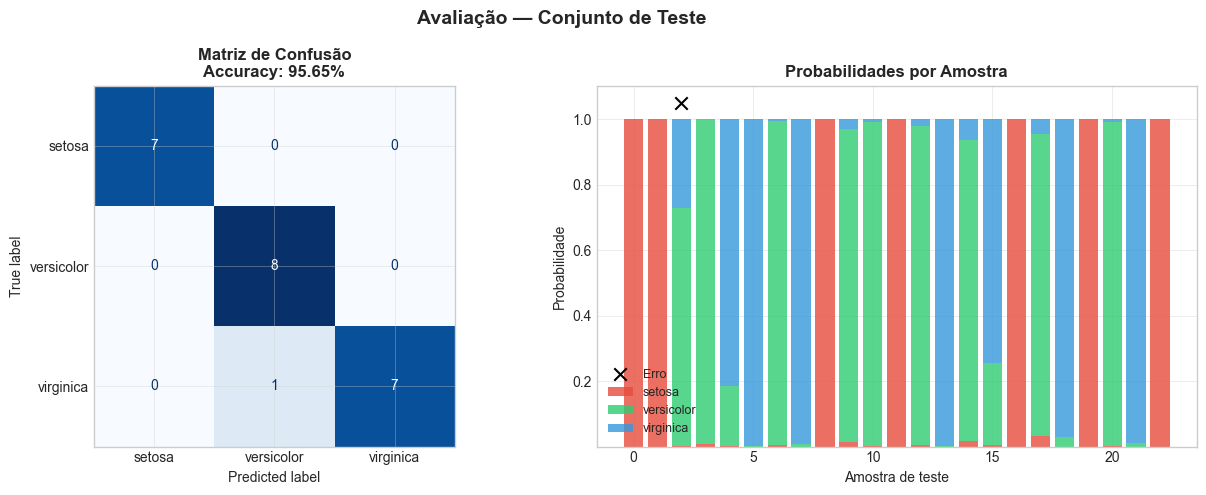

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Avaliação — Conjunto de Teste', fontsize=14, fontweight='bold')

# Matriz de confusão
cm = confusion_matrix(y_test.numpy(), preds_test.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusão\nAccuracy: {acc_test:.2%}', fontsize=12, fontweight='bold')

# Probabilidades preditas por amostra
probs_np = probs_test.numpy()
cores_cls = ['#e74c3c', '#2ecc71', '#3498db']
x_idx = np.arange(len(y_test))
bottom = np.zeros(len(y_test))
for cls_i, (nome, cor) in enumerate(zip(iris.target_names, cores_cls)):
    axes[1].bar(x_idx, probs_np[:, cls_i], bottom=bottom, color=cor, alpha=0.8, label=nome)
    bottom += probs_np[:, cls_i]

# Marcar erros com 'x'
erros = (preds_test.numpy() != y_test.numpy())
if erros.any():
    axes[1].scatter(x_idx[erros], np.ones(erros.sum()) * 1.05,
                    marker='x', color='black', s=80, zorder=5, label='Erro')
axes[1].set_xlabel('Amostra de teste', fontsize=10)
axes[1].set_ylabel('Probabilidade', fontsize=10)
axes[1].set_title('Probabilidades por Amostra', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 11. Predição com Novos Dados

In [21]:
# Novas flores [sepal_length, sepal_width, petal_length, petal_width]
novas_flores_np = np.array([
    [5.1, 3.5, 1.4, 0.2],  # típica setosa
    [6.2, 2.9, 4.3, 1.3],  # típica versicolor
    [7.2, 3.0, 5.8, 1.6],  # típica virginica
    [5.8, 2.7, 4.1, 1.0],  # caso ambíguo
], dtype=np.float32)

# Normalizar com o mesmo scaler do treino
novas_flores_scaled = scaler.transform(novas_flores_np)
novas_flores_tensor = torch.tensor(novas_flores_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    logits_novos = model(novas_flores_tensor)
    probs_novos  = F.softmax(logits_novos, dim=1)
    preds_novos  = logits_novos.argmax(dim=1)

print('=== Predições para Novas Flores ===')
print(f'\n  {"Flor":>4} | {"Predição":>12} | {"setosa":>8} | {"versicolor":>10} | {"virginica":>9}')
print(f'  {"-"*4}-+-{"-"*12}-+-{"-"*8}-+-{"-"*10}-+-{"-"*9}')
for i, (pred, probs) in enumerate(zip(preds_novos, probs_novos)):
    nome = iris.target_names[pred.item()]
    p = probs.numpy()
    print(f'  {i+1:>4} | {nome:>12} | {p[0]:>8.2%} | {p[1]:>10.2%} | {p[2]:>9.2%}')

=== Predições para Novas Flores ===

  Flor |     Predição |   setosa | versicolor | virginica
  -----+--------------+----------+------------+----------
     1 |       setosa |  100.00% |      0.00% |     0.00%
     2 |   versicolor |    0.50% |     98.86% |     0.65%
     3 |    virginica |    0.01% |      7.96% |    92.03%
     4 |   versicolor |    0.17% |     99.74% |     0.09%


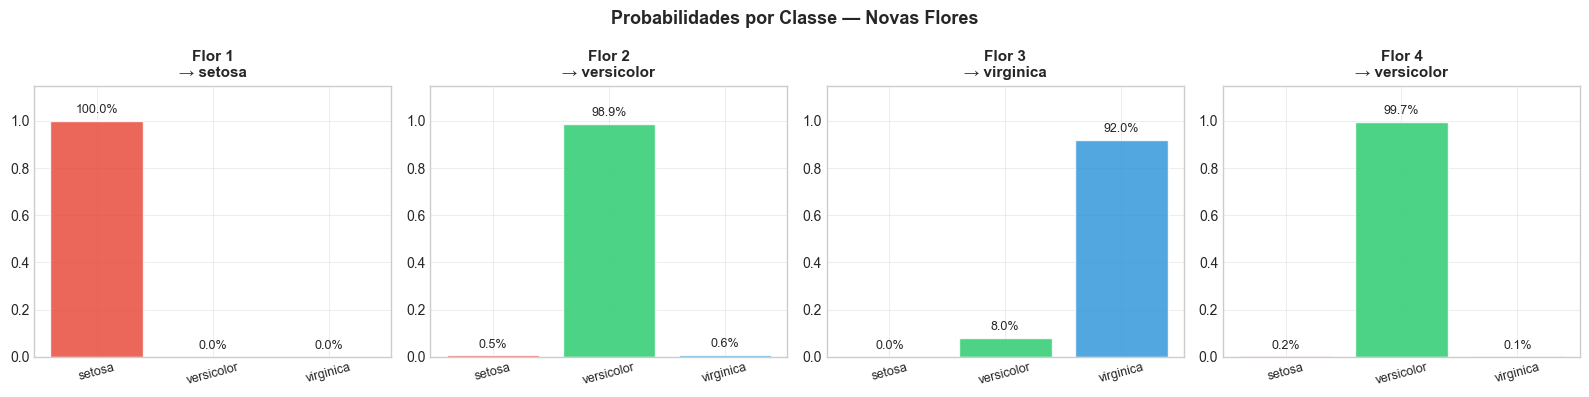

In [28]:
# Visualização das probabilidades das novas flores
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Probabilidades por Classe — Novas Flores', fontsize=13, fontweight='bold')

cores = ['#e74c3c', '#2ecc71', '#3498db']

for i, (ax, probs) in enumerate(zip(axes, probs_novos)):
    p = probs.numpy()
    bars = ax.bar(iris.target_names, p, color=cores, alpha=0.85, edgecolor='white')
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Flor {i+1}\n→ {iris.target_names[preds_novos[i]]}', fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(iris.target_names)))
    ax.set_xticklabels(iris.target_names, rotation=15, fontsize=9)
    for bar, prob in zip(bars, p):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{prob:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


---
## 12. Inspecionando os Pesos da Rede

In [ ]:
print('=== Pesos e Biases da Rede ===')
for nome, param in model.named_parameters():
    print(f'{nome:35s} shape: {list(param.shape):20}  mean={param.data.mean():.4f}  std={param.data.std():.4f}')

In [ ]:
# Visualizar pesos da primeira camada (4 features → 64 neurônios)
weights_l1 = model.network[0].weight.data.numpy()  # shape (64, 4)

plt.figure(figsize=(10, 5))
plt.imshow(weights_l1, cmap='RdBu', aspect='auto')
plt.colorbar(label='Valor do peso')
plt.xlabel('Feature de entrada', fontsize=11)
plt.ylabel('Neurônio na Camada 1', fontsize=11)
plt.title('Pesos da Primeira Camada Linear (64 × 4)', fontsize=13, fontweight='bold')
plt.xticks(range(4), iris.feature_names, rotation=15, fontsize=9)
plt.tight_layout()
plt.show()

print('Vermelho = peso positivo (feature ativa o neurônio)')
print('Azul     = peso negativo (feature inibe o neurônio)')

---
## 13. Salvando e Carregando o Modelo

In [27]:
# Salvar apenas os pesos (recomendado)
torch.save(model.state_dict(), 'iris_net.pth')
print('Modelo salvo em iris_net.pth')

# Carregar o modelo
model_carregado = IrisNet()
model_carregado.load_state_dict(torch.load('iris_net.pth', weights_only=True))
model_carregado.eval()

# Verificar que as predições são idênticas
with torch.no_grad():
    preds_original   = model(X_test).argmax(dim=1)
    preds_carregados = model_carregado(X_test).argmax(dim=1)

print(f'\nPredições idênticas: {torch.all(preds_original == preds_carregados).item()}')
print('\nPara carregar em outro script:')
print("""
  model = IrisNet()
  model.load_state_dict(torch.load('iris_net.pth', weights_only=True))
  model.eval()
""")

Modelo salvo em iris_net.pth

Predições idênticas: True

Para carregar em outro script:

  model = IrisNet()
  model.load_state_dict(torch.load('iris_net.pth', weights_only=True))
  model.eval()



---
## 14. Resumo Final

In [26]:
print('=' * 60)
print('   RESUMO — REDE NEURAL COM PYTORCH (IRIS DATASET)')
print('=' * 60)
print()
print('  PROBLEMA')
print('  Classificação multiclasse (3 espécies de íris)')
print()
print('  ARQUITETURA')
print('  Input(4) → Linear(64) → ReLU → Dropout(0.3)')
print('           → Linear(32) → ReLU → Dropout(0.3)')
print('           → Linear(3)  → CrossEntropyLoss')
print(f'  Parâmetros: {sum(p.numel() for p in model.parameters())}')
print()
print('  CONFIGURAÇÃO DE TREINO')
print('  Loss:      CrossEntropyLoss')
print('  Otimizador: Adam (lr=1e-3)')
print('  Scheduler:  ReduceLROnPlateau')
print(f'  Epochs:     {n_epochs} | Batch size: 16')
print()
print('  RESULTADOS')
print(f'  Train Accuracy:  {calcular_accuracy(model, X_train, y_train):.2%}')
print(f'  Val Accuracy:    {calcular_accuracy(model, X_val, y_val):.2%}')
print(f'  Test Accuracy:   {acc_test:.2%}')
print()
print('  CONCEITOS COBERTOS')
print('  Tensores, Autograd, nn.Module, nn.Sequential')
print('  DataLoader, CrossEntropyLoss, Adam, Scheduler')
print('  Forward/Backward pass, Dropout, state_dict')
print('=' * 60)

   RESUMO — REDE NEURAL COM PYTORCH (IRIS DATASET)

  PROBLEMA
  Classificação multiclasse (3 espécies de íris)

  ARQUITETURA
  Input(4) → Linear(64) → ReLU → Dropout(0.3)
           → Linear(32) → ReLU → Dropout(0.3)
           → Linear(3)  → CrossEntropyLoss
  Parâmetros: 2499

  CONFIGURAÇÃO DE TREINO
  Loss:      CrossEntropyLoss
  Otimizador: Adam (lr=1e-3)
  Scheduler:  ReduceLROnPlateau
  Epochs:     150 | Batch size: 16

  RESULTADOS
  Train Accuracy:  98.10%
  Val Accuracy:    86.36%
  Test Accuracy:   95.65%

  CONCEITOS COBERTOS
  Tensores, Autograd, nn.Module, nn.Sequential
  DataLoader, CrossEntropyLoss, Adam, Scheduler
  Forward/Backward pass, Dropout, state_dict


---
## Próximos Passos

1. **Redes Convolucionais (CNN)** — para imagens (ex: MNIST, CIFAR-10)
2. **Redes Recorrentes (RNN/LSTM)** — para séries temporais e texto
3. **Transfer Learning** — usar modelos pré-treinados (ResNet, BERT)
4. **PyTorch Lightning** — abstração de alto nível para reduzir boilerplate

```python
# Exemplo: CNN simples
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(32 * 14 * 14, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.flatten(1)
        return self.fc(x)
```